# Two View Geometry

## Camera Calibration

We perform **camera calibration** using multiple checkerboard images with known square size (24 mm) and pattern size (10×7).  

For each image, we detect chessboard corners and collect 2D image points and corresponding 3D world points.  

We then estimate the **intrinsic calibration matrix (K)** and distortion coefficients using `cv2.calibrateCamera`, evaluate the reprojection error, and save the calibration parameters for the subsequent geometric steps.

In [1]:
%pip install -U opencv-python

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
os.environ["OPENCV_OPENCL_RUNTIME"] = "disabled"  
os.environ["OPENCV_OPENCL_CACHE_ENABLE"] = "0" 

import glob
import cv2
import numpy as np

cv2.ocl.setUseOpenCL(False) 
import cv2
import numpy as np

cv2.ocl.setUseOpenCL(False) 

pattern_size = (10, 7)      
square_size_mm = 24.0

img_paths = sorted(glob.glob("checkerboard/*.*"))
assert len(img_paths) > 0, "No images found in data/calib/"

cols, rows = pattern_size
objp = np.zeros((rows * cols, 3), np.float32)
objp[:, :2] = np.mgrid[0:cols, 0:rows].T.reshape(-1, 2)
objp *= square_size_mm

objpoints, imgpoints = [], []
img_size = None

os.makedirs("debug_corners", exist_ok=True)

ok = 0
for p in img_paths:
    img = cv2.imread(p)
    if img is None:
        continue
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_size = gray.shape[::-1]

    found, corners = cv2.findChessboardCornersSB(gray, pattern_size)

    if not found:
        print(f"[NO] {os.path.basename(p)}")
        continue

    objpoints.append(objp)
    imgpoints.append(corners)
    ok += 1
    print(f"[OK] {os.path.basename(p)}  corners={len(corners)}")

    vis = img.copy()
    cv2.drawChessboardCorners(vis, pattern_size, corners, found)
    cv2.imwrite(os.path.join("debug_corners", os.path.basename(p)), vis)

print(f"\nFound checkerboards in {ok}/{len(img_paths)} images")
assert ok >= 8, "Too few valid images: try 10–20."

rms, K, dist, rvecs, tvecs = cv2.calibrateCamera(
    objpoints, imgpoints, img_size, None, None
)

mean_err = 0.0
for i in range(len(objpoints)):
    proj, _ = cv2.projectPoints(objpoints[i], rvecs[i], tvecs[i], K, dist)
    err = cv2.norm(imgpoints[i], proj, cv2.NORM_L2) / np.sqrt(len(proj))
    mean_err += err
mean_err /= len(objpoints)

print("\n=== RESULTS ===")
print("RMS (calibrateCamera):", rms)
print("Mean reprojection error (px):", mean_err)
print("\nK =\n", K)
print("\ndist =\n", dist.ravel())

np.savez("camera_calib.npz",
         K=K, dist=dist, rms=rms, mean_reproj_error=mean_err,
         img_size=np.array(img_size), pattern_size=np.array(pattern_size),
         square_size_mm=square_size_mm)
print("\nSaved: camera_calib.npz")
print("Debug corners saved in: debug_corners/")

[OK] DSCF6455.JPG  corners=70
[OK] DSCF6456.JPG  corners=70
[OK] DSCF6457.JPG  corners=70
[OK] DSCF6458.JPG  corners=70
[OK] DSCF6459.JPG  corners=70
[OK] DSCF6460.JPG  corners=70
[OK] DSCF6461.JPG  corners=70
[OK] DSCF6462.JPG  corners=70
[OK] DSCF6463.JPG  corners=70
[OK] DSCF6464.JPG  corners=70
[OK] DSCF6465.JPG  corners=70
[OK] DSCF6466.JPG  corners=70
[OK] DSCF6467.JPG  corners=70
[NO] DSCF6468.JPG
[OK] DSCF6469.JPG  corners=70
[OK] DSCF6470.JPG  corners=70
[OK] DSCF6471.JPG  corners=70
[OK] DSCF6472.JPG  corners=70
[NO] DSCF6473.JPG
[OK] DSCF6474.JPG  corners=70
[OK] DSCF6475.JPG  corners=70
[OK] DSCF6476.JPG  corners=70
[OK] DSCF6477.JPG  corners=70
[OK] DSCF6478.JPG  corners=70
[OK] DSCF6479.JPG  corners=70
[OK] DSCF6480.JPG  corners=70
[OK] DSCF6481.JPG  corners=70
[OK] DSCF6482.JPG  corners=70
[OK] DSCF6483.JPG  corners=70
[OK] DSCF6484.JPG  corners=70
[OK] DSCF6485.JPG  corners=70
[OK] DSCF6486.JPG  corners=70
[NO] DSCF6487.JPG
[NO] DSCF6488.JPG
[OK] DSCF6489.JPG  corners=7

## Matches via SIFT

We extract **SIFT keypoints and descriptors** from the two grayscale images and match them using a **Brute-Force matcher with L2 distance**.  

We apply **Lowe’s ratio test** (ratio = 0.65) to retain only reliable correspondences and discard ambiguous matches.  

Finally, we store the matched **pixel coordinates** (still distorted, from the original images) for the subsequent geometric estimation steps (e.g., Essential matrix computation).

In [ ]:
import os
import cv2
import numpy as np

img1_path = "object/img1.JPG"
img2_path = "object/img2.JPG"

out_dir = "outputs"
os.makedirs(out_dir, exist_ok=True)

img1 = cv2.imread(img1_path)
img2 = cv2.imread(img2_path)
assert img1 is not None and img2 is not None, "Error: images not found. Check paths."

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

feat = cv2.SIFT_create(nfeatures=5000)
norm = cv2.NORM_L2
ratio = 0.7

# ------------------------------------------------------------

kp1, des1 = feat.detectAndCompute(gray1, None)
kp2, des2 = feat.detectAndCompute(gray2, None)
assert des1 is not None and des2 is not None, "No descriptors found."

bf = cv2.BFMatcher(norm, crossCheck=False)
matches_knn = bf.knnMatch(des1, des2, k=2)

good = []
for m, n in matches_knn:
    if m.distance < ratio * n.distance:
        good.append(m)

print(f"Keypoints: img1={len(kp1)} img2={len(kp2)}")
print(f"Matches after ratio test: {len(good)}")
assert len(good) >= 12, "Too few matches: try changing ratio o use images with more texture."

pts1 = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 2)
pts2 = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 2)

# Visualisation of post-ratio-test matches
vis = cv2.drawMatches(
    img1, kp1, img2, kp2,
    good, None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)
cv2.imwrite(os.path.join(out_dir, "good_matches.png"), vis)

# Save post-ratio-test matches
np.savez(
    os.path.join(out_dir, "matches_px.npz"),
    pts1=pts1,
    pts2=pts2,
    undistorted=np.array([0], dtype=np.int32),  
    use_sift=np.array([1], dtype=np.int32),  
    ratio=np.array([ratio], dtype=np.float64),
)

print("Saved:")
print(" - outputs/good_matches.png")
print(" - outputs/matches_px.npz")

Keypoints: img1=5000 img2=5001
Matches after ratio test: 331
Saved:
 - outputs/good_matches.png
 - outputs/matches_px.npz


## Eight point algorithm for essential matrix estimation

We estimate the **Essential matrix (E)** from SIFT and optional manual correspondences using a normalized 8-point algorithm with RANSAC.  

First, we undistort the matched pixel coordinates and convert them into **normalized camera coordinates** (using \( K^{-1} \)), so the epipolar constraint is enforced in metric space.  

We then apply **Hartley normalization** for numerical stability, solve the linear system via SVD, enforce the rank-2 constraint on \(E\), and use **RANSAC (5000 iterations, Sampson error threshold = 5e-7)** to robustly select inliers and refit the final model.

In [4]:
import os
import glob
import numpy as np
import cv2

CALIB_PATH   = "camera_calib.npz"
MATCHES_PATH = "outputs/matches_px.npz"
IMG1_PATH    = "object/img1.JPG"
IMG2_PATH    = "object/img2.JPG"

OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

RANSAC_ITERS = 5000
RANSAC_THRESH = 5e-7
RANSAC_SEED = 0

cal = np.load(CALIB_PATH)
K = cal["K"].astype(np.float64)
dist = cal["dist"].astype(np.float64)

m = np.load(MATCHES_PATH, allow_pickle=True)

pts1_in = m["pts1"].astype(np.float64)
pts2_in = m["pts2"].astype(np.float64)

matches_undistorted = int(m["undistorted"][0]) if "undistorted" in m else 0

if matches_undistorted == 1:
    pts1_sift_u_px = pts1_in
    pts2_sift_u_px = pts2_in
else:
    pts1_sift_u_px = cv2.undistortPoints(pts1_in.reshape(-1,1,2), K, dist, P=K).reshape(-1,2)
    pts2_sift_u_px = cv2.undistortPoints(pts2_in.reshape(-1,1,2), K, dist, P=K).reshape(-1,2)

img1 = cv2.imread(IMG1_PATH)
img2 = cv2.imread(IMG2_PATH)
assert img1 is not None and img2 is not None, "Images not read: check the paths."

img1_u = cv2.undistort(img1, K, dist)
img2_u = cv2.undistort(img2, K, dist)
cv2.imwrite(os.path.join(OUT_DIR, "img1_undistorted.png"), img1_u)
cv2.imwrite(os.path.join(OUT_DIR, "img2_undistorted.png"), img2_u)

def load_all_manual_points(out_dir):
    files = sorted(glob.glob(os.path.join(out_dir, "*.npz")))
    pts1_list, pts2_list = [], []
    used_files = []

    for f in files:
        try:
            d = np.load(f, allow_pickle=True)
            if "pts1" not in d or "pts2" not in d:
                continue
            p1 = d["pts1"].astype(np.float64)
            p2 = d["pts2"].astype(np.float64)

            n = min(len(p1), len(p2))
            if n < 1:
                continue
            p1 = p1[:n]
            p2 = p2[:n]

            und_flag = int(d["undistorted"][0]) if "undistorted" in d else 0
            if und_flag == 1:
                p1_u = p1
                p2_u = p2
            else:
                p1_u = cv2.undistortPoints(p1.reshape(-1,1,2), K, dist, P=K).reshape(-1,2)
                p2_u = cv2.undistortPoints(p2.reshape(-1,1,2), K, dist, P=K).reshape(-1,2)

            pts1_list.append(p1_u)
            pts2_list.append(p2_u)
            used_files.append(os.path.basename(f))
        except Exception as e:
            print(f" Skip {os.path.basename(f)}: {e}")

    if len(pts1_list) == 0:
        return None, None, used_files

    return np.vstack(pts1_list), np.vstack(pts2_list), used_files

MANUAL_DIR = "manual_points"
pts1_man_u_px, pts2_man_u_px, manual_files_used = load_all_manual_points(MANUAL_DIR)

if pts1_man_u_px is not None:
    pts1_u_px = np.vstack([pts1_sift_u_px, pts1_man_u_px])
    pts2_u_px = np.vstack([pts2_sift_u_px, pts2_man_u_px])
    src_is_manual = np.hstack([
        np.zeros(len(pts1_sift_u_px), dtype=bool),
        np.ones(len(pts1_man_u_px), dtype=bool),
    ])
    print(f"Manual points added: {len(pts1_man_u_px)} (from {len(manual_files_used)} files)")
else:
    pts1_u_px = pts1_sift_u_px
    pts2_u_px = pts2_sift_u_px
    src_is_manual = np.zeros(len(pts1_u_px), dtype=bool)
    print("No manual_high_precision*.npz file found: using only SIFT/ORB.")

print(f"Total correspondences used (SIFT+MANUAL): {len(pts1_u_px)}")
assert len(pts1_u_px) >= 8, "Need at least 8 total correspondences (SIFT+manual)."

pts1_norm = cv2.undistortPoints(pts1_u_px.reshape(-1,1,2), K, None).reshape(-1,2)
pts2_norm = cv2.undistortPoints(pts2_u_px.reshape(-1,1,2), K, None).reshape(-1,2)

def to_hom(pts2d):
    return np.hstack([pts2d, np.ones((pts2d.shape[0], 1), dtype=np.float64)])

def hartley_normalize_2d(x):
    mu = np.mean(x, axis=0)
    x0 = x - mu
    d = np.sqrt(np.sum(x0**2, axis=1))
    mean_d = np.mean(d) + 1e-12
    s = np.sqrt(2.0) / mean_d

    T = np.array([
        [s, 0, -s*mu[0]],
        [0, s, -s*mu[1]],
        [0, 0, 1]
    ], dtype=np.float64)

    x_h = to_hom(x)
    x_nh = (T @ x_h.T).T
    x_n = x_nh[:, :2] / x_nh[:, 2:3]
    return x_n, T

def eight_point_E(x1, x2, do_preconditioning=True):
    if do_preconditioning:
        x1n, T1 = hartley_normalize_2d(x1)
        x2n, T2 = hartley_normalize_2d(x2)
    else:
        x1n, x2n = x1, x2
        T1 = T2 = np.eye(3)

    x1x, x1y = x1n[:, 0], x1n[:, 1]
    x2x, x2y = x2n[:, 0], x2n[:, 1]

    A = np.column_stack([
        x2x*x1x, x2x*x1y, x2x,
        x2y*x1x, x2y*x1y, x2y,
        x1x,     x1y,     np.ones_like(x1x)
    ])

    _, _, Vt = np.linalg.svd(A)
    E_tilde = Vt[-1].reshape(3, 3)

    E = T2.T @ E_tilde @ T1

    U, S, Vt = np.linalg.svd(E)
    s = 0.5*(S[0] + S[1])
    E = U @ np.diag([s, s, 0.0]) @ Vt
    return E

def sampson_error(E, x1, x2):
    x1h = to_hom(x1)
    x2h = to_hom(x2)

    Ex1 = (E @ x1h.T).T
    Etx2 = (E.T @ x2h.T).T
    x2tEx1 = np.sum(x2h * Ex1, axis=1)

    denom = Ex1[:,0]**2 + Ex1[:,1]**2 + Etx2[:,0]**2 + Etx2[:,1]**2
    return (x2tEx1**2) / (denom + 1e-12)

def ransac_eight_point(x1, x2, iters=5000, threshold=1e-6, seed=0):
    rng = np.random.default_rng(seed)
    N = len(x1)
    assert N >= 8, "Need at least 8 matches."

    best_E = None
    best_mask = None
    best_inliers = -1
    best_score = np.inf

    for _ in range(iters):
        idx = rng.choice(N, size=8, replace=False)
        E_cand = eight_point_E(x1[idx], x2[idx], do_preconditioning=True)

        err = sampson_error(E_cand, x1, x2)
        mask = err < threshold
        n_in = int(np.sum(mask))
        if n_in < 8:
            continue

        score = float(np.mean(err[mask]))

        if (n_in > best_inliers) or (n_in == best_inliers and score < best_score):
            best_inliers = n_in
            best_E = E_cand
            best_mask = mask
            best_score = score

    assert best_E is not None and best_mask is not None, "RANSAC did not find a valid model."

    E_refit = eight_point_E(x1[best_mask], x2[best_mask], do_preconditioning=True)

    err_refit = sampson_error(E_refit, x1, x2)
    mask_refit = err_refit < threshold

    if int(np.sum(mask_refit)) >= 8 and int(np.sum(mask_refit)) >= int(best_inliers * 0.8):
        return E_refit, mask_refit
    else:
        return best_E, best_mask


E_8r, mask_8r = ransac_eight_point(
    pts1_norm, pts2_norm,
    iters=RANSAC_ITERS,
    threshold=RANSAC_THRESH,
    seed=RANSAC_SEED
)
assert E_8r is not None and mask_8r is not None, "RANSAC 8-point failed."

err_8_all = sampson_error(E_8r, pts1_norm, pts2_norm)

print("\n=== 8-POINT + RANSAC (SIFT + MANUAL) ===")
print("Inliers:", int(np.sum(mask_8r)), "/", len(mask_8r))
print("E_8_ransac =\n", E_8r)
print("Sampson mean (inliers):", float(np.mean(err_8_all[mask_8r])))
print("Sampson median (inliers):", float(np.median(err_8_all[mask_8r])))

n_in_manual = int(np.sum(mask_8r & src_is_manual))
n_in_sift = int(np.sum(mask_8r & (~src_is_manual)))
print(f"Inlier breakdown: SIFT={n_in_sift}, MANUAL={n_in_manual}")


np.savez(
    os.path.join(OUT_DIR, "E_results.npz"),
    E_8=E_8r,
    sampson_8=err_8_all,
    mask_8=mask_8r.astype(bool),

    pts1_px=pts1_u_px.astype(np.float64),
    pts2_px=pts2_u_px.astype(np.float64),
    pts1_norm=pts1_norm.astype(np.float64),
    pts2_norm=pts2_norm.astype(np.float64),

    K=K.astype(np.float64),
    src_is_manual=src_is_manual.astype(bool),
    manual_files=np.array(manual_files_used, dtype=object)
)

print("\nSaved in outputs/:")
print(" - img1_undistorted.png, img2_undistorted.png")
print(" - E_results.npz  (includes E_8, mask_8, pts, K, SIFT+MANUAL)")

Manual points added: 282 (from 24 files)
Total correspondences used (SIFT+MANUAL): 613

=== 8-POINT + RANSAC (SIFT + MANUAL) ===
Inliers: 575 / 613
E_8_ransac =
 [[-0.01290363  0.47581216  0.12278306]
 [ 0.15199653 -0.1161378  -5.98155558]
 [-0.12002863  5.96473257 -0.12936151]]
Sampson mean (inliers): 9.293551415899643e-08
Sampson median (inliers): 5.96312925716454e-08
Inlier breakdown: SIFT=318, MANUAL=257

Saved in outputs/:
 - img1_undistorted.png, img2_undistorted.png
 - E_results.npz  (includes E_8, mask_8, pts, K, SIFT+MANUAL)


##  Epipolar lines plot

We convert the estimated **Essential matrix (E)** into the **Fundamental matrix (F)** using $ F = K^{-T} E K^{-1} $, so epipolar lines can be expressed in pixel coordinates.  

For each inlier point in image 2, we compute the corresponding **epipolar line in image 1** using $ \ell = F^T x_2 $.  

Finally, we draw a subset of these epipolar lines on the undistorted image to visually verify the geometric consistency of the estimated model.

In [5]:
def draw_epilines_on_img1(img1_u, pts1_u_px, pts2_u_px, F, out_path):
    H, W = img1_u.shape[:2]
    vis = img1_u.copy()

    idx = np.arange(len(pts2_u_px))

    for i in idx:
        x2 = np.array([pts2_u_px[i,0], pts2_u_px[i,1], 1.0], dtype=np.float64)
        a, b, c = (F.T @ x2)

        pts = []
        if abs(b) > 1e-9:
            y0 = int(round((-c - a*0) / b))
            yW = int(round((-c - a*(W-1)) / b))
            pts = [(0, y0), (W-1, yW)]
        elif abs(a) > 1e-9:
            x = int(round(-c / a))
            pts = [(x, 0), (x, H-1)]

        if len(pts) == 2:
            cv2.line(vis, pts[0], pts[1], (0, 255, 0), 1)  

        
        pt1 = (int(round(pts1_u_px[i, 0])), int(round(pts1_u_px[i, 1])))
        
        
        cv2.circle(vis, pt1, 8, (0, 0, 255), -1)

    cv2.imwrite(out_path, vis)


F_8r = np.linalg.inv(K).T @ E_8r @ np.linalg.inv(K)

draw_epilines_on_img1(
    img1_u,
    pts1_u_px[mask_8r],  
    pts2_u_px[mask_8r],
    F_8r,
    out_path=os.path.join(OUT_DIR, "epilines_img1_8point_RANSAC.png")
)

## Comparison with 5-Point OpenCV

We estimate the **Essential matrix** using OpenCV’s built-in **5-point algorithm with RANSAC** (`cv2.findEssentialMat`) on normalized camera coordinates.  

If multiple candidate solutions are returned, we select the one that yields the best pose (maximum inliers) using `cv2.recoverPose`.  

Finally, we evaluate the model via **Sampson error**, convert $E$ to the Fundamental matrix $F$, and draw the corresponding epipolar lines to visually compare the result with our custom 8-point implementation.

In [6]:
E_cv, mask_cv = cv2.findEssentialMat(
    pts1_norm.reshape(-1,1,2),
    pts2_norm.reshape(-1,1,2),
    np.eye(3),
    method=cv2.RANSAC,
    prob=0.999,
    threshold=7.07e-4
)

mask_cv = mask_cv.ravel().astype(bool)

# Pick the best E if OpenCV returns multiple solutions (stacked 3N x 3)
if E_cv.shape[0] > 3:
    best_E = None
    best_score = -1
    best_pose_mask = None

    mask_u8 = mask_cv.astype(np.uint8).reshape(-1, 1)
    for i in range(0, E_cv.shape[0], 3):
        Ei = E_cv[i:i+3, :]
        try:
            score, R_tmp, t_tmp, pose_mask = cv2.recoverPose(
                Ei,
                pts1_norm.reshape(-1,1,2),
                pts2_norm.reshape(-1,1,2),
                np.eye(3),
                mask=mask_u8
            )
        except cv2.error:
            continue

        if score > best_score:
            best_score = score
            best_E = Ei
            best_pose_mask = pose_mask

    if best_E is None:
        E_cv = E_cv[:3, :3]
    else:
        E_cv = best_E
        mask_cv = best_pose_mask.ravel().astype(bool)

err_cv_all = sampson_error(E_cv, pts1_norm, pts2_norm)

print("\n=== OPENCV 5-POINT (RANSAC) ===")
print("Inliers:", int(np.sum(mask_cv)), "/", len(mask_cv))
print("E_cv =\n", E_cv)
print("Sampson mean (inliers):", float(np.mean(err_cv_all[mask_cv])))
print("Sampson median (inliers):", float(np.median(err_cv_all[mask_cv])))

F_cv = np.linalg.inv(K).T @ E_cv @ np.linalg.inv(K)

draw_epilines_on_img1(
    img1_u,
    pts1_u_px[mask_cv],
    pts2_u_px[mask_cv],
    F_cv,
    out_path=os.path.join(OUT_DIR, "epilines_img1_opencv5pt.png")
)



=== OPENCV 5-POINT (RANSAC) ===
Inliers: 566 / 613
E_cv =
 [[-0.00163145  0.04441     0.01824374]
 [ 0.02368124 -0.01356249 -0.70631976]
 [-0.01582139  0.70539095 -0.01527082]]
Sampson mean (inliers): 5.0353869566054275e-08
Sampson median (inliers): 7.220881138062945e-09


In [7]:
# Comparison

#def normalize_E(E):
#    return E / np.linalg.norm(E)

#err8_all = sampson_error(normalize_E(E_8r), pts1_norm, pts2_norm)
#err5_all = sampson_error(normalize_E(E_cv),  pts1_norm, pts2_norm)

# Errors on ALL matches (same evaluation set)
err8_all = sampson_error(E_8r, pts1_norm, pts2_norm)
err5_all = sampson_error(E_cv,  pts1_norm, pts2_norm)

m8 = mask_8r.astype(bool)
m5 = mask_cv.astype(bool)
mint = m8 & m5

def show(tag, mask):
    print(f"\n--- {tag} ---")
    print("8pt  mean/median:", float(err8_all[mask].mean()), float(np.median(err8_all[mask])))
    print("5pt  mean/median:", float(err5_all[mask].mean()), float(np.median(err5_all[mask])))
    print("count:", int(mask.sum()), "/", len(mask))

show("ALL matches", np.ones(len(m8), dtype=bool))
show("8pt inliers (m8)", m8)
show("5pt inliers (m5)", m5)
show("Intersection (m8 & m5)", mint)


def pct_stats(err, mask, pcts=(50, 75, 90, 95, 99)):
    vals = err[mask]
    return {p: float(np.percentile(vals, p)) for p in pcts}

all_mask = np.ones(len(m8), dtype=bool)

print("\nPercentiles on ALL matches (Sampson):")
print("8pt:", pct_stats(err8_all, all_mask))
print("5pt:", pct_stats(err5_all, all_mask))

m_extra = m8 & (~m5)
print("\n--- Extra inliers accepted only by 8pt ---")
print("count:", int(m_extra.sum()))
print("8pt mean/median:", float(err8_all[m_extra].mean()), float(np.median(err8_all[m_extra])))
print("5pt mean/median:", float(err5_all[m_extra].mean()), float(np.median(err5_all[m_extra])))

tp = int((m8 & m5).sum())        # both inlier
fp = int((m8 & ~m5).sum())       # only 8pt inlier
fn = int((~m8 & m5).sum())       # only 5pt inlier
tn = int((~m8 & ~m5).sum())      # both outlier

print("\nMask agreement counts:")
print("both inlier:", tp)
print("8pt only:", fp)
print("5pt only:", fn)
print("both outlier:", tn)

def tail_mean(err, q=90):
    thr = np.percentile(err, q)
    tail = err[err >= thr]
    return float(tail.mean()), float(thr), int(tail.size)

m_all = np.ones(len(err8_all), dtype=bool)
mean_tail8, thr8, n8 = tail_mean(err8_all[m_all], 90)
mean_tail5, thr5, n5 = tail_mean(err5_all[m_all], 90)

print("\nTail (worst 10%) on ALL matches:")
print("8pt: tail-mean =", mean_tail8, " 90th% thr =", thr8, " count =", n8)
print("5pt: tail-mean =", mean_tail5, " 90th% thr =", thr5, " count =", n5)

# Manual vs SIFT breakdown
is_man = src_is_manual.astype(bool)

m_both = m8 & m5
m_8_only = m8 & (~m5)      # accepted by 8pt, rejected by 5pt 
m_5_only = (~m8) & m5      # accepted by 5pt, rejected by 8pt
m_none = (~m8) & (~m5)

def breakdown(tag, mask):
    n = int(mask.sum())
    n_man = int((mask & is_man).sum())
    n_sift = int((mask & (~is_man)).sum())
    print(f"{tag}: total={n}, MANUAL={n_man}, SIFT={n_sift}")

print("\n=== Manual/SIFT breakdown by agreement set ===")
breakdown("Both inliers", m_both)
breakdown("8pt only", m_8_only)
breakdown("5pt only", m_5_only)
breakdown("Both outliers", m_none)

print("\nManual points rejected by 5pt but accepted by 8pt:",
      int((m_8_only & is_man).sum()))


--- ALL matches ---
8pt  mean/median: 6.55090401194552e-05 6.759851293481509e-08
5pt  mean/median: 6.575678893673847e-05 1.1675314919010303e-08
count: 613 / 613

--- 8pt inliers (m8) ---
8pt  mean/median: 9.293551415899643e-08 5.96312925716454e-08
5pt  mean/median: 7.737559044192613e-08 7.734378935136682e-09
count: 575 / 613

--- 5pt inliers (m5) ---
8pt  mean/median: 1.0272267018629082e-07 5.96312925716454e-08
5pt  mean/median: 5.0353869566054275e-08 7.220881138062945e-09
count: 566 / 613

--- Intersection (m8 & m5) ---
8pt  mean/median: 8.89760503286368e-08 5.8220982278526836e-08
5pt  mean/median: 4.724323172001646e-08 7.063830339638215e-09
count: 557 / 613

Percentiles on ALL matches (Sampson):
8pt: {50: 6.759851293481509e-08, 75: 1.6869839451408986e-07, 90: 2.836798248180869e-07, 95: 7.182018602260797e-07, 99: 1.5153374723183561e-05}
5pt: {50: 1.1675314919010303e-08, 75: 8.599844900194684e-08, 90: 3.468500416929797e-07, 95: 1.3001579633888505e-06, 99: 2.1206502013805078e-05}

--- 

## 3D Reconstruction and Visualization 

We recover the relative camera pose $(R, t)$ from our estimated **Essential matrix (E₈)** using only its RANSAC inliers, ensuring full consistency with our custom pipeline.  

We then **triangulate 3D points** in normalized camera coordinates and apply cheirality and distance filtering to keep only physically valid and stable points.  

Finally, we visualize the reconstructed 3D point cloud in Plotly, coloring SIFT points from the undistorted image, highlighting manual points in red, and optionally displaying the two camera centers.

In [8]:
%pip install -U plotly

Note: you may need to restart the kernel to use updated packages.


E_8 + mask_8 used (no fallback to OpenCV)
Reconstructed points: 512 (SIFT=255, MANUAL=257)


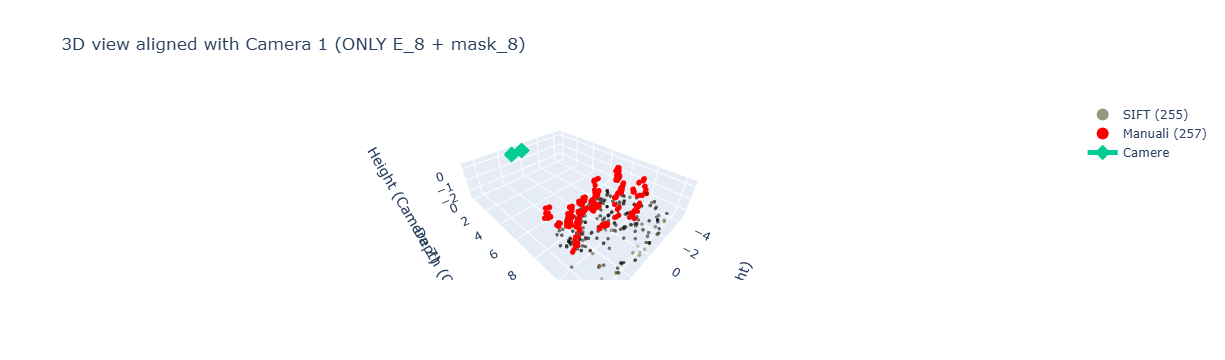

In [9]:
import os
import sys
import numpy as np
import cv2
import plotly.graph_objects as go

SHOW_CAMERAS = True

IMG1_PATH = "object/img1.JPG"
CALIB_PATH = "camera_calib.npz"
E_RES_PATH = "outputs/E_results.npz"

OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

img1 = cv2.imread(IMG1_PATH)
assert img1 is not None, "Error loading img1."
img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

cal = np.load(CALIB_PATH)
K = cal["K"].astype(np.float64)
dist = cal["dist"].astype(np.float64)

# Undistort img1 for correct color sampling of non-manual points
img1_u = cv2.undistort(img1, K, dist)
img1_u_rgb = cv2.cvtColor(img1_u, cv2.COLOR_BGR2RGB)

res = np.load(E_RES_PATH, allow_pickle=True)

# ------------------------------------------------------------
# Use the Essential Matrix E coming from the 8-point

if "E_8" not in res:
    raise RuntimeError("E_8 not found in E_results.npz: regenerate step 2, saving E_8.")
E = res["E_8"].astype(np.float64)

if "mask_8" not in res:
    raise RuntimeError(
        "mask_8 is not present in E_results.npz.\n"
        "Regenerate E_results.npz using step 2 that saves mask_8."
    )
mask_in = res["mask_8"].astype(bool)
print("E_8 + mask_8 used (no fallback to OpenCV)")

# ------------------------------------------------------------

if "pts1_px" not in res or "pts1_norm" not in res or "pts2_norm" not in res:
    raise RuntimeError(
        "The file E_results.npz is missing pts1_px / pts1_norm / pts2_norm.\n"
        "Make sure that step 2 saves these arrays."
    )

pts1_px = res["pts1_px"].astype(np.float64)
pts1_norm = res["pts1_norm"].astype(np.float64)
pts2_norm = res["pts2_norm"].astype(np.float64)

src_is_manual = res["src_is_manual"].astype(bool) if "src_is_manual" in res else np.zeros(len(pts1_px), dtype=bool)

pts1_n = pts1_norm[mask_in].reshape(-1, 1, 2)
pts2_n = pts2_norm[mask_in].reshape(-1, 1, 2)
pts1_p = pts1_px[mask_in]
is_manual = src_is_manual[mask_in]

# ------------------------------------------------------------

# recoverPose
retval, R, t, mask_pose = cv2.recoverPose(E, pts1_n, pts2_n, np.eye(3))
mask_pose = mask_pose.ravel().astype(bool)

pts1_final_n = pts1_n[mask_pose].reshape(-1, 2)
pts2_final_n = pts2_n[mask_pose].reshape(-1, 2)
pts1_final_px = pts1_p[mask_pose].astype(np.int32)
is_manual_final = is_manual[mask_pose]

# ------------------------------------------------------------

# Triangulation on normalized coordinates
P1 = np.hstack([np.eye(3), np.zeros((3, 1))])
P2 = np.hstack([R, t])

X_h = cv2.triangulatePoints(P1, P2, pts1_final_n.T, pts2_final_n.T)
X = (X_h[:3, :] / (X_h[3, :] + 1e-12)).T

# ------------------------------------------------------------

pts1_final_u_px = cv2.undistortPoints(
    pts1_final_px.reshape(-1, 1, 2).astype(np.float64),
    K, dist, P=K
).reshape(-1, 2)
pts1_final_u_px = np.rint(pts1_final_u_px).astype(np.int32)

colors_rgb = []
h0, w0 = img1_rgb.shape[:2]
h1, w1 = img1_u_rgb.shape[:2]
for i, pt in enumerate(pts1_final_px):
    if is_manual_final[i]:
        u, v = int(pt[0]), int(pt[1])
        v = int(np.clip(v, 0, h0 - 1))
        u = int(np.clip(u, 0, w0 - 1))
        c = img1_rgb[v, u] / 255.0
    else:
        u, v = int(pts1_final_u_px[i, 0]), int(pts1_final_u_px[i, 1])
        v = int(np.clip(v, 0, h1 - 1))
        u = int(np.clip(u, 0, w1 - 1))
        c = img1_u_rgb[v, u] / 255.0
    colors_rgb.append(c)
colors_rgb = np.asarray(colors_rgb, dtype=np.float64)

# Filters
X2 = (R @ X.T + t).T
mask_cheir = (X[:, 2] > 0) & (X2[:, 2] > 0)

dists_all = np.linalg.norm(X, axis=1)
th = np.quantile(dists_all[mask_cheir], 0.9) if np.sum(mask_cheir) > 0 else np.inf
mask_dist = dists_all < th

mask_keep = mask_cheir & mask_dist
X = X[mask_keep]
colors_rgb = colors_rgb[mask_keep]
is_manual_final = is_manual_final[mask_keep]

n_sift = int(np.sum(~is_manual_final))
n_manual = int(np.sum(is_manual_final))
print(f"Reconstructed points: {len(X)} (SIFT={n_sift}, MANUAL={n_manual})")

# ------------------------------------------------------------

def transform_to_plot(pts):
    x_p = pts[:, 0]
    y_p = pts[:, 2]
    z_p = -pts[:, 1]
    return x_p, y_p, z_p

def camera_center_from_Rt(R, t):
    return (-R.T @ t).reshape(3)

def rgb_str(c):
    r, g, b = (np.clip(c, 0, 1) * 255).astype(int)
    return f"rgb({r},{g},{b})"

sift_mask = ~is_manual_final
manual_mask = is_manual_final

data = []

# ------------------------------------------------------------

# SIFT cloud
if np.sum(sift_mask) > 0:
    xs, ys, zs = transform_to_plot(X[sift_mask])
    cols = [rgb_str(c) for c in colors_rgb[sift_mask]]
    data.append(go.Scatter3d(
        x=xs, y=ys, z=zs,
        mode="markers",
        name=f"SIFT ({n_sift})",
        marker=dict(size=2, color=cols, opacity=0.65)
    ))

# Manual points
if np.sum(manual_mask) > 0:
    xm, ym, zm = transform_to_plot(X[manual_mask])
    data.append(go.Scatter3d(
        x=xm, y=ym, z=zm,
        mode="markers",
        name=f"Manuali ({n_manual})",
        marker=dict(size=3, color="red", opacity=1.0)
    ))

# Cameras
if SHOW_CAMERAS:
    C1 = np.zeros(3)
    C2 = camera_center_from_Rt(R, t)
    C_plot = np.vstack([C1, C2])
    xc, yc, zc = transform_to_plot(C_plot)

    data.append(go.Scatter3d(
        x=xc, y=yc, z=zc,
        mode="markers+lines",
        name="Camere",
        marker=dict(size=6, symbol="diamond"),
        line=dict(width=5)
    ))

fig = go.Figure(data=data)

fig.update_layout(
    title="3D view aligned with Camera 1 (ONLY E_8 + mask_8)",
    scene=dict(
        xaxis_title="X (Left-Right)",
        yaxis_title="Depth (Camera Y)",
        zaxis_title="Height (Camera Z)",
        aspectmode="data" 
    ),
    legend=dict(itemsizing="constant")
)

fig.show()